# 02. Friction Comparison
**Objective:** Evaluate the the performance of the [previously introduced](01_Frictionless_Baselines.ipynb) models on historical data with realistic frictions enabled ([12 bps commission and slippage](../config.yaml)), as well as Monte Carlo Simulations based on different models. Besides comparison and evaluation, the goal is to narrow down the candidate models for the regime aware composite model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle as pkl

from model_setup import models_to_test, models_to_test_frictionless

from src.utils.metrics import calculate_metrics

In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{lmodern} \usepackage[T1]{fontenc} \usepackage{amsmath} \usepackage{amssymb}",
        "font.family": "serif",
        "font.serif": ["Latin Modern Roman"],
    }
)

In [3]:
stock_data = pd.read_csv(
    "../data/raw/stock_data_comparison.csv", index_col=0, parse_dates=True
)

index_data = pd.read_csv(
    "../data/raw/index_data_comparison.csv", index_col=0, parse_dates=True
)

In [4]:
tested_models = []
tested_models_frictionless = []

In [5]:
for model in models_to_test:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_models.append(testing_model)

In [6]:
for model in models_to_test_frictionless:
    testing_model = model["class"](assets=stock_data, **model["kwargs"])
    testing_model.run_backtest()
    testing_model.calculate_performance_metrics()
    tested_models_frictionless.append(testing_model)

Firstly we can examine the performance of the models relative to each other and to their frictionless version. With the frictionless versions being denoted with the star marker.

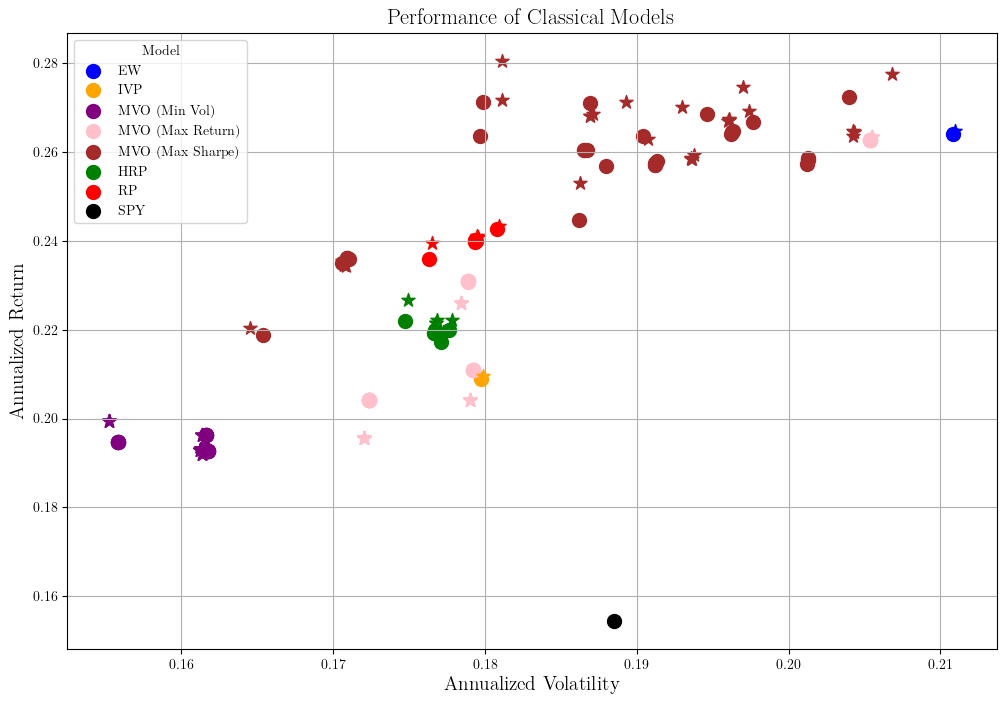

In [7]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models", fontsize=16)

for i, model in enumerate(tested_models):
    name = models_to_test[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:9] == "MVO_min_v":
            name = "MVO (Min Vol)"
        elif name[:9] == "MVO_max_s":
            name = "MVO (Max Sharpe)"
        elif name[:9] == "MVO_max_r":
            name = "MVO (Max Return)"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO (Min Vol)":
        color = "purple"
    elif name == "MVO (Max Sharpe)":
        color = "brown"
    elif name == "MVO (Max Return)":
        color = "pink"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

for i, model in enumerate(tested_models_frictionless):
    name = models_to_test_frictionless[i]["name"]
    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:9] == "MVO_min_v":
            name = "MVO (Min Vol)"
        elif name[:9] == "MVO_max_s":
            name = "MVO (Max Sharpe)"
        elif name[:9] == "MVO_max_r":
            name = "MVO (Max Return)"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO (Min Vol)":
        color = "purple"
    elif name == "MVO (Max Sharpe)":
        color = "brown"
    elif name == "MVO (Max Return)":
        color = "pink"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
        marker="*",
    )


spy_metrics = calculate_metrics(index_data["SPY"].values)


plt.scatter(
    spy_metrics["Annualized Volatility"],
    spy_metrics["Annualized Return"],
    label="SPY",
    color="black",
    s=100,
)


plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

x_lim = plt.gca().get_xlim()
y_lim = plt.gca().get_ylim()

plt.show()

Turning on realistic frictions introduced visible performance degradation in generak, as it was expected. Interestingly The MVO portfolios with the maximum return goal increased their performance, but still underperform compared to the other objectives.

In [8]:
metrics_list = []
for i, model in enumerate(tested_models):
    metrics = model.performance_metrics.copy()
    metrics["Model"] = models_to_test[i]["name"]
    metrics_list.append(metrics)

df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index("Model", inplace=True)

if "Sharpe Ratio" in df_metrics.columns:
    df_metrics.sort_values(by="Max Drawdown", ascending=False, inplace=True)

df_metrics.round(4)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,VAR (95%),ES (95%),Skewness,Kurtosis
Model,,,,,,,,,,
EW,0.2640,0.2108,1.2525,1.4535,0.3317,0.7961,0.0188,0.0326,-0.6455,16.5730
MVO_max_return_historical_cov_equilibrium_ret,0.2628,0.2054,1.2794,1.4852,0.3205,0.8199,0.0180,0.0319,-0.5935,16.2013
MVO_max_return_ledoit_wolf_cov_equilibrium_ret,0.2628,0.2054,1.2794,1.4852,0.3205,0.8199,0.0180,0.0319,-0.5935,16.2013
MVO_max_return_FF_3_cov_equilibrium_ret,0.2628,0.2054,1.2794,1.4852,0.3205,0.8199,0.0180,0.0319,-0.5935,16.2013
MVO_max_return_FF_5_cov_equilibrium_ret,0.2628,0.2054,1.2794,1.4852,0.3205,0.8199,0.0180,0.0319,-0.5935,16.2013
...,...,...,...,...,...,...,...,...,...,...
MVO_max_sharpe_Carhart_4_cov_FF_3_ret,0.2572,0.1912,1.3447,1.6540,0.2272,1.1317,0.0177,0.0290,-0.0691,13.3955
MVO_max_sharpe_FF_3_cov_FF_3_ret,0.2574,0.1912,1.3463,1.6551,0.2272,1.1330,0.0177,0.0290,-0.0695,13.4040
MVO_max_sharpe_FF_5_cov_FF_3_ret,0.2571,0.1912,1.3449,1.6533,0.2272,1.1318,0.0177,0.0290,-0.0692,13.4105


We can arrive at similar conclusions based on the detailed performance metrics as well. Even though the introduction of costs decreases performance MVO based models still perform well compared to others. However historical data is only one realisation of the underlying probability distribution, thus it is worthwile to create Monte Carlo based evaluation. We created different types of parametric and non parametric methods. To identify the most appropriate one we will calculate the Wasserstein distance for each asset and the covariance matrix as well, and choose the most appropriate one based solely on the performance in the learning dataset.

In [9]:
from mc_selection import distance_summary

In [10]:
distances = distance_summary()
distances

,Average asset distance,Covariance distance
static_normal,0.004971,0.004833
static_student_t,0.001073,0.020735
static_skewed_t,0.000951,0.016136
dynamic_skewed_t,0.001860,0.031040
historical_bootstrap,0.000679,0.009368
static_normal_hmm,0.007538,0.047820
static_student_t_hmm,0.001444,0.024260
static_skewed_t_hmm,0.001335,0.027523
dynamic_skewed_t_hmm,0.003120,0.088247


If we look at the distances between the historical and model distributions we can see an interesting pattern. The fitted multivariate normal distribution with static covariance structure is the worst in terms of individual assets, as expected, however it can capture the covariance structure surprisingly well. Interestingly the regime aware simulators ("*_hmm") performed worse on the individual assets but better in the covariance estimation. Based on this we decided to use the skewed t simulator with static covariance structure. It performs incredibly well on the individual asset level and reasonably well on the covariance front as indicated by the distances and also provides great simulation performance.

With this in place it is worthwile to not only visualize the performance of these models on the historical data, but the results of the Monte Carlo simulations as well.

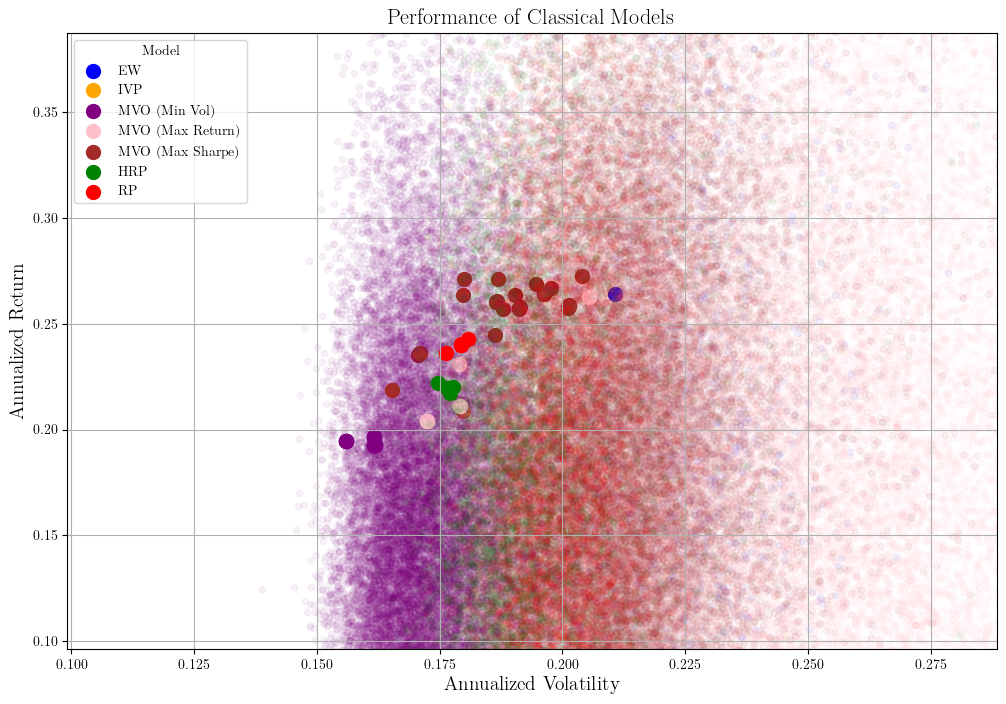

In [11]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models", fontsize=16)

for i, model in enumerate(tested_models):
    name = models_to_test[i]["name"]

    with open(
        f"../data/mc_metrics/{name}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:9] == "MVO_min_v":
            name = "MVO (Min Vol)"
        elif name[:9] == "MVO_max_s":
            name = "MVO (Max Sharpe)"
        elif name[:9] == "MVO_max_r":
            name = "MVO (Max Return)"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO (Min Vol)":
        color = "purple"
    elif name == "MVO (Max Sharpe)":
        color = "brown"
    elif name == "MVO (Max Return)":
        color = "pink"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

    plt.scatter(
        mc_metrics["Annualized Volatility"],
        mc_metrics["Annualized Return"],
        s=20,
        alpha=0.05,
        color=color,
    )


plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

mult = 0.35

x_lim_mc = (x_lim[0] * (1 - mult), x_lim[1] * (1 + mult))
y_lim_mc = (y_lim[0] * (1 - mult), y_lim[1] * (1 + mult))

plt.gca().set_xlim(x_lim_mc)
plt.gca().set_ylim(y_lim_mc)

plt.show()

However as we estaplished previously it is only worth examining the maximum sharpe objective MVO portfolios:

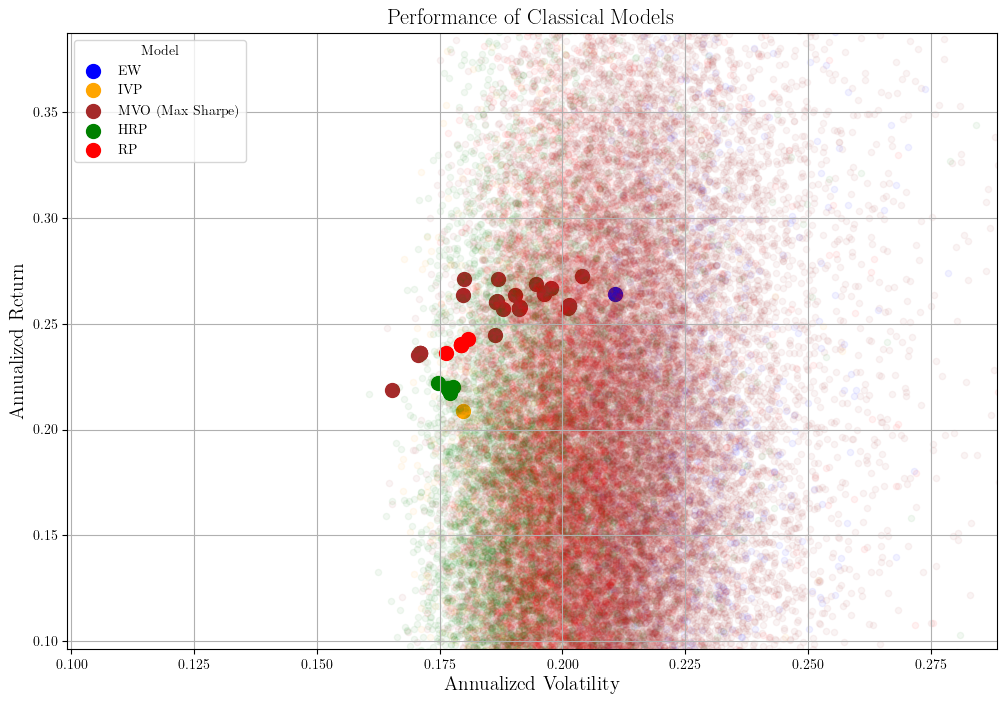

In [12]:
fig = plt.figure(figsize=(12, 8))

plt.title("Performance of Classical Models", fontsize=16)

for i, model in enumerate(tested_models):
    name = models_to_test[i]["name"]

    with open(
        f"../data/mc_metrics/{name}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    if len(name) > 3:
        if name[:2] == "RP":
            name = "RP"
        elif name[:3] == "IVP":
            name = "IVP"
        elif name[:3] == "HRP":
            name = "HRP"
        elif name[:9] == "MVO_min_v":
            continue
            name = "MVO (Min Vol)"
        elif name[:9] == "MVO_max_s":
            name = "MVO (Max Sharpe)"
        elif name[:9] == "MVO_max_r":
            continue
            name = "MVO (Max Return)"
    if name == "EW":
        color = "blue"
    elif name == "IVP":
        color = "orange"
    elif name == "HRP":
        color = "green"
    elif name == "RP":
        color = "red"
    elif name == "MVO (Min Vol)":
        color = "purple"
    elif name == "MVO (Max Sharpe)":
        color = "brown"
    elif name == "MVO (Max Return)":
        color = "pink"
    plt.scatter(
        model.performance_metrics["Annualized Volatility"],
        model.performance_metrics["Annualized Return"],
        label=name,
        color=color,
        s=100,
    )

    plt.scatter(
        mc_metrics["Annualized Volatility"],
        mc_metrics["Annualized Return"],
        s=20,
        alpha=0.05,
        color=color,
    )


plt.xlabel("Annualized Volatility", fontsize=14)
plt.ylabel("Annualized Return", fontsize=14)
plt.grid()

handles, labels = plt.gca().get_legend_handles_labels()
unique = [
    (h, l) for k, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:k]
]
plt.legend(*zip(*unique), title="Model")

mult = 0.35

x_lim_mc = (x_lim[0] * (1 - mult), x_lim[1] * (1 + mult))
y_lim_mc = (y_lim[0] * (1 - mult), y_lim[1] * (1 + mult))

plt.gca().set_xlim(x_lim_mc)
plt.gca().set_ylim(y_lim_mc)

plt.show()

It is interesting to see that MC simulation consistently results in a higher volatility and a very large dispersion in the potential returns. Let us examine the different performance metrics associated with the MC simulation. To characterize their distribution we will be using the mean, variance, mind and max.

In [13]:
metrics_list = []
for i, model in enumerate(tested_models):

    metrics = model.performance_metrics.copy()

    if ("MVO_min_v" in models_to_test[i]["name"]) or (
        "MVO_max_r" in models_to_test[i]["name"]
    ):
        continue

    with open(
        f"../data/mc_metrics/{models_to_test[i]["name"]}_static_skewed_t_MC_backtest_results.pkl",
        "rb",
    ) as f:
        mc_metrics = pkl.load(f)

    for key in list(metrics.keys()):
        metrics[f"{key} Mean"] = np.mean(mc_metrics[key])
        metrics[f"{key} Std"] = np.std(mc_metrics[key])
        metrics[f"{key} Min"] = np.min(mc_metrics[key])
        metrics[f"{key} Max"] = np.max(mc_metrics[key])

    metrics["Model"] = models_to_test[i]["name"]
    metrics_list.append(metrics)


df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index("Model", inplace=True)

df_metrics = df_metrics.reindex(sorted(df_metrics.columns), axis=1)


if "Sharpe Ratio" in df_metrics.columns:
    df_metrics.sort_values(by="Max Drawdown", ascending=False, inplace=True)

df_metrics.round(4)

,Annualized Return,Annualized Return Max,Annualized Return Mean,Annualized Return Min,Annualized Return Std,Annualized Volatility,Annualized Volatility Max,Annualized Volatility Mean,Annualized Volatility Min,Annualized Volatility Std,...,Sortino Ratio,Sortino Ratio Max,Sortino Ratio Mean,Sortino Ratio Min,Sortino Ratio Std,VAR (95%),VAR (95%) Max,VAR (95%) Mean,VAR (95%) Min,VAR (95%) Std
Model,,,,,,,,,,,,,,,,,,,,,
EW,0.2640,0.6391,0.1718,-0.1915,0.1181,0.2108,0.3014,0.2264,0.1950,0.0130,...,1.4535,5.0331,1.1800,-1.2515,0.8426,0.0188,0.0254,0.0201,0.0172,0.0011
IVP,0.2089,0.4991,0.1536,-0.0964,0.1003,0.1797,0.2614,0.1908,0.1643,0.0129,...,1.2700,4.4605,1.2391,-0.6194,0.8410,0.0159,0.0206,0.0169,0.0141,0.0009
RP_Carhart_4_cov,0.2398,0.6835,0.1648,-0.0906,0.1044,0.1794,0.2920,0.1996,0.1724,0.0112,...,1.4750,5.9860,1.2792,-0.7302,0.8452,0.0152,0.0209,0.0178,0.0148,0.0009
RP_FF_3_cov,0.2399,0.5993,0.1685,-0.1361,0.1051,0.1794,0.3192,0.2012,0.1727,0.0133,...,1.4756,5.2892,1.3036,-1.0828,0.8520,0.0152,0.0214,0.0178,0.0154,0.0009
RP_FF_5_cov,0.2400,0.5153,0.1625,-0.1311,0.1016,0.1794,0.2721,0.2001,0.1731,0.0120,...,1.4766,3.9668,1.2551,-0.9250,0.8153,0.0152,0.0206,0.0178,0.0150,0.0009
HRP_historical_cov,0.2173,0.5233,0.1595,-0.0846,0.0942,0.1771,0.2711,0.1911,0.1606,0.0120,...,1.3481,4.6598,1.2835,-0.6487,0.8031,0.0149,0.0205,0.0170,0.0143,0.0009
RP_ledoit_wolf_cov,0.2426,0.6042,0.1682,-0.1547,0.1012,0.1808,0.2968,0.2030,0.1771,0.0121,...,1.4923,5.6582,1.2864,-1.0037,0.8125,0.0154,0.0211,0.0180,0.0152,0.0009
HRP_ledoit_wolf_cov,0.2200,0.7211,0.1585,-0.1246,0.0969,0.1777,0.2543,0.1932,0.1671,0.0127,...,1.3648,6.3353,1.2733,-0.9347,0.8123,0.0149,0.0204,0.0172,0.0148,0.0009
RP_historical_cov,0.2402,0.4717,0.1571,-0.1600,0.1060,0.1794,0.2680,0.2001,0.1780,0.0118,...,1.4790,3.8689,1.2190,-1.1616,0.8578,0.0152,0.0210,0.0178,0.0155,0.0009


If we look at the metrics we can arrive at the expected conclusion, while MVO can provide excellent returns it is prone to high drawdowns as evidenced by the drawdown statistics in the metrics dataframe. On the other hand HRP methods provide a slightly less average return but provide a significantly less average drawdown metric. Thus it would be advisable to combine to strengths of the two models with a regime detection method. Thus going forward we will only be looking at the best 2 models in case of models that only use covariance estimation and the top 5 models that use both covariance and return estimation based on their avarage sharpe ratios. This leads to the following models used for the development and evaluation of the rHMM-MVO model:

1. Equal weight portfolio
2. Inverse volatility weighted portfolio
3. Mean-variance portfolio with max sharpe objective, Carhart factor covariance estimator and historical return estimator
4. Mean-variance portfolio with max sharpe objective, Fama-French 3 factor covariance estimator and historical return estimator
5. Mean-variance portfolio with max sharpe objective, exponentially weighted covariance estimator and historical return estimator 
6. Mean-variance portfolio with max sharpe objective, historical covariance estimator and historical return estimator
7. Mean-variance portfolio with max sharpe objective, Fama-French 5 factor covariance estimator and historical return estimator
8. Hierachical risk parity portfolio with with historical covariance estimator
9. Hierachical risk parity portfolio with with Ledoit-Wolf covariance estimator 
10. Risk parity portfolio with Fama-French 3 factor covariance estimator
11. Risk parity portfolio with Ledoit-Wolf covariance estimator